In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from tqdm.auto import tqdm

# Hugging Face imports
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

set_seed(42)

In [2]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Success! PyTorch is using: {gpu_name}")
    print(f"Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
else:
    print("Error: PyTorch cannot find the GPU. Go to Runtime > Change runtime type > Select T4 GPU.")

Success! PyTorch is using: NVIDIA A100-SXM4-40GB
Memory Usage: 0.00 GB


In [3]:
CONFIG = {
    # 1. Paths
    "TRAIN_DIR": "dataset/subtask3/train/",
    "DEV_DIR": "dataset/subtask3/dev/",
    "SAVE_DIR": "models/subtask3/",
    "PREDICTION_DIR": "predictions/subtask3/",

    # 2. Data Settings
    "MAX_LEN": 128,
    "BATCH_SIZE": 8,
    "GRAD_ACC_STEPS": 4,

    # 3. Subtask 3 Labels
    "LABEL_COLS": [
        'stereotype',
        'vilification',
        'dehumanization',
        'extreme_language',
        'lack_of_empathy',
        'invalidation'
    ],

    # 4. Model Candidates
    "MODELS": {
        "xlm-roberta": "xlm-roberta-base",
        "mdeberta": "microsoft/mdeberta-v3-base",
        "rembert": "google/rembert",
        "mbert": "bert-base-multilingual-cased",
        "distilmbert": "distilbert-base-multilingual-cased"
    }
}

TRAIN_PARAMS = {
    "EPOCHS": 10,
    "LEARNING_RATE": 2e-5,
    "MAX_GRAD_NORM": 1.0,
    "WARMUP_RATIO": 0.1,
    "WEIGHT_DECAY": 0.01,
    "PATIENCE": 3,
}

In [4]:
from google.colab import drive
import os
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Update the Configuration to point to the Drive Shortcut
# We assume you added the shortcut to "My Drive" and named it "NLP"
base_path = "/content/drive/MyDrive/NLP Project/subtask3/"

CONFIG["TRAIN_DIR"] = os.path.join(base_path, "train/")
CONFIG["DEV_DIR"]   = os.path.join(base_path, "dev/")

# 3. Verify the connection
if os.path.exists(CONFIG["TRAIN_DIR"]):
    print(f"Success! Found Train Directory: {CONFIG['TRAIN_DIR']}")
    print(f"   Files found: {len(os.listdir(CONFIG['TRAIN_DIR']))}")
else:
    print(f"Error: Train Directory not found: {CONFIG['TRAIN_DIR']}")

if os.path.exists(CONFIG["DEV_DIR"]):
    print(f"Success! Found Train Directory: {CONFIG['DEV_DIR']}")
    print(f"   Files found: {len(os.listdir(CONFIG['DEV_DIR']))}")
else:
    print(f"Error: Train Directory not found: {CONFIG['DEV_DIR']}")

Mounted at /content/drive
Success! Found Train Directory: /content/drive/MyDrive/NLP Project/subtask3/train/
   Files found: 12
Success! Found Train Directory: /content/drive/MyDrive/NLP Project/subtask3/dev/
   Files found: 12


In [5]:
def load_and_merge_data(directory, label_columns):
    """
    Loads all CSV files from a directory, merges them, and ensures
    all Subtask 3 label columns exist (filling missing ones with 0).
    """
    # Find all csv files
    all_files = glob.glob(os.path.join(directory, "*.csv"))

    if not all_files:
        raise ValueError(f"No CSV files found in {directory}!")

    df_list = []
    print(f"\nLoading data from: {directory}")

    for filename in sorted(all_files):
        lang_code = os.path.basename(filename).split('.')[0] # e.g., 'english' from 'english.csv'
        try:
            df = pd.read_csv(filename)

            # Basic cleaning: rename 'Text' to 'text' if needed
            df.columns = [c.lower() for c in df.columns]

            if 'text' not in df.columns:
                print(f"  ⚠️ Skipping {filename}: No 'text' column found.")
                continue

            # Add language column for analysis later
            df['language'] = lang_code

            # Ensure all Target Labels exist
            # (Some language files might miss specific columns if no examples exist)
            for col in label_columns:
                if col not in df.columns:
                    # Create the missing column with 0s
                    df[col] = 0

            # Keep only relevant columns: id, text, language, and the labels
            keep_cols = ['id', 'text', 'language'] + label_columns
            # Filter to keep only columns that actually exist in the dataframe
            keep_cols = [c for c in keep_cols if c in df.columns]

            df_list.append(df[keep_cols])
            print(f"  ✅ Loaded {lang_code}: {len(df)} rows")

        except Exception as e:
            print(f"  ❌ Error loading {filename}: {e}")

    # Merge all languages
    combined_df = pd.concat(df_list, axis=0, ignore_index=True)

    # Fill any remaining NaNs in label columns with 0 (Crucial for Multi-label)
    combined_df[label_columns] = combined_df[label_columns].fillna(0).astype(int)

    print(f"Total merged samples: {len(combined_df)}")
    return combined_df

# === EXECUTE LOADING ===
print("--- Loading Training Data ---")
full_train_df = load_and_merge_data(CONFIG['TRAIN_DIR'], CONFIG['LABEL_COLS'])

#dev_df = load_and_merge_data(CONFIG['DEV_DIR'], CONFIG['LABEL_COLS'])

train_df, local_val_df = train_test_split(
    full_train_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"✅ Data Split Complete:")
print(f"   - Training Set:   {len(train_df)} samples (Model learns from this)")
print(f"   - Validation Set: {len(local_val_df)} samples (Model is tested on this for F1 Score)")

# C. Load the Unlabelled Dev Data (For Final Submission only)
# We call this 'submission_df' to avoid confusion.
submission_df_raw = load_and_merge_data(CONFIG['DEV_DIR'], CONFIG['LABEL_COLS'])
print(f"   - Submission Set: {len(submission_df_raw)} samples (Unlabelled - for Leaderboard)")

# Preview
train_df.head()

--- Loading Training Data ---

Loading data from: /content/drive/MyDrive/NLP Project/subtask3/train/
  ✅ Loaded amh: 3332 rows
  ✅ Loaded arb: 3380 rows
  ✅ Loaded deu: 3180 rows
  ✅ Loaded eng: 2676 rows
  ✅ Loaded fas: 3295 rows
  ✅ Loaded hau: 3651 rows
  ✅ Loaded hin: 2744 rows
  ✅ Loaded nep: 2005 rows
  ✅ Loaded spa: 3305 rows
  ✅ Loaded tur: 2364 rows
  ✅ Loaded urd: 2849 rows
  ✅ Loaded zho: 4280 rows
Total merged samples: 37061
✅ Data Split Complete:
   - Training Set:   29648 samples (Model learns from this)
   - Validation Set: 7413 samples (Model is tested on this for F1 Score)

Loading data from: /content/drive/MyDrive/NLP Project/subtask3/dev/
  ✅ Loaded amh: 166 rows
  ✅ Loaded arb: 169 rows
  ✅ Loaded deu: 159 rows
  ✅ Loaded eng: 133 rows
  ✅ Loaded fas: 164 rows
  ✅ Loaded hau: 182 rows
  ✅ Loaded hin: 137 rows
  ✅ Loaded nep: 100 rows
  ✅ Loaded spa: 165 rows
  ✅ Loaded tur: 115 rows
  ✅ Loaded urd: 142 rows
  ✅ Loaded zho: 214 rows
Total merged samples: 1846
   - Su

,id,text,language,stereotype,vilification,dehumanization,extreme_language,lack_of_empathy,invalidation
26922,spa_9ae51a48a8e35d97889ac2e76831f60b,me encantaria que tuvieras los para decircelo ...,spa,1,0,0,0,1,0
20326,hin_13632ea8575661add4f989e8b77f38ad,अभी भी ये लोग दुनिया के विकास और टेक्नोलॉजी का...,hin,1,1,1,1,0,1
286,amh_32dd80c10ea80492d92221f11721e137,ከወደ መቀሌ አሁን የተሰማ መረጃ አደገኛወቹ ጁንታወች ምሽግ ውስጥ ተከበዋ...,amh,1,1,0,0,0,0
7850,deu_e257fa0b458835e931fb0a2825b6b3ab,Kann man das so allgemein fassen? Gibt doch be...,deu,0,0,0,0,0,0
16281,hau_d015b99ccc7779950048b2026e0a9062,"kuchuma cc @USER ""@USER : “@USER : u remind me...",hau,0,0,0,0,0,0


In [6]:
# ============================================================================
# CALCULATE CLASS WEIGHTS
# ============================================================================
# We calculate positive weights for BCEWithLogitsLoss
# Formula: pos_weight = (num_negatives / num_positives)

# 1. Get counts for each label
label_counts = train_df[CONFIG['LABEL_COLS']].sum()
total_samples = len(train_df)

# 2. Calculate weights
pos_weights = []
print(f"{'Label':<20} | {'Count':<8} | {'Weight (Alpha)':<8}")
print("-" * 45)

for label in CONFIG['LABEL_COLS']:
    n_pos = label_counts[label]
    n_neg = total_samples - n_pos

    # Avoid division by zero
    if n_pos == 0:
        weight = 1.0
    else:
        weight = n_neg / n_pos

    pos_weights.append(weight)
    print(f"{label:<20} | {n_pos:<8} | {weight:.2f}")

# 3. Convert to Tensor (Move to GPU later)
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float)

Label                | Count    | Weight (Alpha)
---------------------------------------------
stereotype           | 9558     | 2.10
vilification         | 10685    | 1.77
dehumanization       | 3885     | 6.63
extreme_language     | 7867     | 2.77
lack_of_empathy      | 5847     | 4.07
invalidation         | 5150     | 4.76


In [7]:
# ============================================================================
# DATASET CLASS & TOKENIZER
# ============================================================================

# 1. Initialize Tokenizer
# We use the 'xlm-roberta' key from your CONFIG['MODELS']
MODEL_NAME = CONFIG['MODELS']['rembert']
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded Tokenizer: {MODEL_NAME}")

# 2. Define the Dataset Class
class PolarizationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, label_cols):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_cols = label_cols
        self.texts = dataframe['text'].values
        self.targets = dataframe[label_cols].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = str(self.texts[index])

        # Preprocessing: Basic cleaning often helps XLM-R
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            # Convert targets to Float for BCE Loss
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

# 3. Create Dataset Objects
#train_dataset = PolarizationDataset(train_df, tokenizer, CONFIG['MAX_LEN'], CONFIG['LABEL_COLS'])
#dev_dataset = PolarizationDataset(dev_df, tokenizer, CONFIG['MAX_LEN'], CONFIG['LABEL_COLS'])
train_dataset = PolarizationDataset(train_df, tokenizer, CONFIG['MAX_LEN'], CONFIG['LABEL_COLS'])
val_dataset = PolarizationDataset(local_val_df, tokenizer, CONFIG['MAX_LEN'], CONFIG['LABEL_COLS'])

print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Dev Dataset:   {len(local_val_df)} samples")

# Quick sanity check: Print one sample
sample = train_dataset[0]
print("\nSample Output Shape:")
print(f" IDs:     {sample['ids'].shape}")
print(f" Targets: {sample['targets']}")

tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

sentencepiece.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Loaded Tokenizer: google/rembert
Train Dataset: 29648 samples
Dev Dataset:   7413 samples

Sample Output Shape:
 IDs:     torch.Size([128])
 Targets: tensor([1., 0., 0., 0., 1., 0.])


In [8]:
# ============================================================================
# DATA LOADERS
# ============================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,          # Shuffle training data
    num_workers=2,         # Speed up loading
    pin_memory=True        # Speed up transfer to GPU
)

dev_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,         # Do NOT shuffle validation data
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Dev batches:   {len(dev_loader)}")

Train batches: 3706
Dev batches:   927


In [9]:
def calculate_metrics(pred_logits, true_labels, threshold=0.15):
    """
    Calculates Macro F1, Per-Class Precision/Recall for Multi-label classification.
    """
    # 1. Convert Logits to Probabilities (Sigmoid)
    pred_probs = torch.sigmoid(pred_logits).cpu().detach().numpy()
    true_labels = true_labels.cpu().detach().numpy()

    # 2. Convert Probabilities to Binary (0 or 1) based on threshold
    pred_binary = (pred_probs > threshold).astype(int)

    # 3. Calculate Metrics
    # Macro F1 is the official ranking metric for SemEval
    macro_f1 = f1_score(true_labels, pred_binary, average='macro', zero_division=0)
    micro_f1 = f1_score(true_labels, pred_binary, average='micro', zero_division=0)

    # 4. Per-Class Metrics (Crucial for your Error Analysis Report)
    per_class_precision = precision_score(true_labels, pred_binary, average=None, zero_division=0)
    per_class_recall = recall_score(true_labels, pred_binary, average=None, zero_division=0)
    per_class_f1 = f1_score(true_labels, pred_binary, average=None, zero_division=0)

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "per_class_precision": per_class_precision,
        "per_class_recall": per_class_recall,
        "per_class_f1": per_class_f1
    }

In [10]:
def find_best_threshold_per_class(model, loader, device, label_cols):
    model.eval()
    all_probs = []
    all_targets = []

    print("📊 Generating predictions to find optimal thresholds...")

    with torch.no_grad():
        for batch in tqdm(loader):
            ids = batch['ids'].to(device, dtype=torch.long)
            mask = batch['mask'].to(device, dtype=torch.long)
            targets = batch['targets'].to(device, dtype=torch.float)

            outputs = model(input_ids=ids, attention_mask=mask)
            probs = torch.sigmoid(outputs.logits)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Concatenate all batches
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets)

    optimal_thresholds = []

    print(f"\n{'Label':<20} | {'Best Thresh':<12} | {'Best F1':<10}")
    print("-" * 50)

    # Loop through EACH label column (0 to 5)
    for i, label in enumerate(label_cols):
        best_f1 = 0
        best_thresh = 0.5

        # Check thresholds for THIS specific label
        for thresh in np.arange(0.05, 0.96, 0.05):
            y_pred = (y_prob[:, i] > thresh).astype(int)
            f1 = f1_score(y_true[:, i], y_pred, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        optimal_thresholds.append(best_thresh)
        print(f"{label:<20} | {best_thresh:<12.2f} | {best_f1:.4f}")

    return optimal_thresholds

In [11]:
import pandas as pd

def generate_predictions(model, dataframe, tokenizer, max_len, device, thresholds, label_cols, output_path):

    print(f"\nGenerating Predictions to: {output_path}")

    # 1. Create a temporary Dataset/Loader for the input data
    # (Reusing your existing Dataset class structure)
    class PredDataset(Dataset):
        def __init__(self, texts, tokenizer, max_len):
            self.texts = texts
            self.tokenizer = tokenizer
            self.max_len = max_len
        def __len__(self): return len(self.texts)
        def __getitem__(self, index):
            text = str(self.texts[index])
            inputs = self.tokenizer.encode_plus(
                text, None, add_special_tokens=True, max_length=self.max_len,
                padding='max_length', truncation=True, return_token_type_ids=False,
                return_attention_mask=True, return_tensors='pt'
            )
            return {
                'ids': inputs['input_ids'].flatten(),
                'mask': inputs['attention_mask'].flatten()
            }

    pred_dataset = PredDataset(dataframe['text'].values, tokenizer, max_len)
    pred_loader = DataLoader(pred_dataset, batch_size=32, shuffle=False)

    # 2. Get Raw Probabilities
    model.eval()
    all_logits = []
    print("   Running Inference...")
    with torch.no_grad():
        for batch in tqdm(pred_loader):
            ids = batch['ids'].to(device, dtype=torch.long)
            mask = batch['mask'].to(device, dtype=torch.long)
            outputs = model(input_ids=ids, attention_mask=mask)
            all_logits.append(outputs.logits)

    all_logits = torch.cat(all_logits, dim=0)
    pred_probs = torch.sigmoid(all_logits).cpu().numpy()

    # 3. Apply Optimal Thresholds
    print(f"   Applying Thresholds: {thresholds}")
    pred_binary = np.zeros_like(pred_probs, dtype=int)
    for i, thresh in enumerate(thresholds):
        pred_binary[:, i] = (pred_probs[:, i] > thresh).astype(int)

    # 4. Save to CSV
    submission_df = dataframe[['id']].copy() # Keep IDs
    for i, label in enumerate(label_cols):
        submission_df[label] = pred_binary[:, i]

    submission_df.to_csv(output_path, index=False)
    print("   ✅ Done!")
    return submission_df

In [12]:
os.makedirs(CONFIG['SAVE_DIR'], exist_ok=True)
os.makedirs(CONFIG['PREDICTION_DIR'], exist_ok=True)
print(f"✅ Created directories: {CONFIG['SAVE_DIR']} and {CONFIG['PREDICTION_DIR']}")

# We save the current state (Epoch 10)
emergency_save_path = os.path.join(CONFIG['SAVE_DIR'], "rembert_epoch10_rescue.bin")
torch.save(model.state_dict(), emergency_save_path)
print(f"✅ Model saved to: {emergency_save_path}")

# We need to see the ACTUAL probabilities.
print("\n📊 RUNNING DIAGNOSTICS...")
model.eval()
all_probs = []

with torch.no_grad():
    # Only run on the first 5 batches to save time
    for i, batch in enumerate(dev_loader):
        if i > 5: break
        ids = batch['ids'].to(device, dtype=torch.long)
        mask = batch['mask'].to(device, dtype=torch.long)
        outputs = model(input_ids=ids, attention_mask=mask)
        probs = torch.sigmoid(outputs.logits)
        all_probs.append(probs.cpu().numpy())

combined_probs = np.concatenate(all_probs)

print(f"\n🔍 RAW PROBABILITY STATS:")
print(f"   Max Probability predicted: {combined_probs.max():.6f}")
print(f"   Avg Probability predicted: {combined_probs.mean():.6f}")
print(f"   Min Probability predicted: {combined_probs.min():.6f}")

print("\n--- Interpretation ---")
if combined_probs.max() < 0.5:
    print("⚠️  The model is 'shy'. Even its most confident prediction is below 0.5.")
    print("    This explains why F1 is 0.00. We need to use a much lower threshold.")
else:
    print("✅  The model has confident predictions > 0.5.")

✅ Created directories: models/subtask3/ and predictions/subtask3/


NameError: name 'model' is not defined

In [13]:
# ============================================================================
# TRAINING SETUP
# ============================================================================

print(f"Loading Model: {MODEL_NAME}...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CONFIG['LABEL_COLS']),
    problem_type="multi_label_classification"
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=TRAIN_PARAMS['LEARNING_RATE'], weight_decay=TRAIN_PARAMS['WEIGHT_DECAY'])
total_steps = len(train_loader) * TRAIN_PARAMS['EPOCHS']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * TRAIN_PARAMS['WARMUP_RATIO']),
    num_training_steps=total_steps
)

#Define Weighted Loss Function
label_counts = train_df[CONFIG['LABEL_COLS']].sum()
pos_weights = [ (len(train_df) - c) / c if c > 0 else 1.0 for c in label_counts ]
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# TRAINING LOOP
best_val_f1 = 0
patience_counter = 0

print(f"\nStarting Training for {TRAIN_PARAMS['EPOCHS']} Epochs...")
print(f"   Batch Size: {CONFIG['BATCH_SIZE']} | Grad Accumulation: {CONFIG['GRAD_ACC_STEPS']}")

for epoch in range(TRAIN_PARAMS['EPOCHS']):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0

    loop = tqdm(train_loader, leave=True)
    for step, batch in enumerate(loop):
        # Move batch to GPU
        ids = batch['ids'].to(device, dtype=torch.long)
        mask = batch['mask'].to(device, dtype=torch.long)
        targets = batch['targets'].to(device, dtype=torch.float)

        # Forward Pass
        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits

        # Calculate Weighted Loss
        loss = criterion(logits, targets)

        # Normalize loss for Gradient Accumulation
        loss = loss / CONFIG['GRAD_ACC_STEPS']
        loss.backward()
        total_train_loss += loss.item()

        # Backward Pass (only update weights every GRAD_ACC_STEPS)
        if (step + 1) % CONFIG['GRAD_ACC_STEPS'] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_PARAMS['MAX_GRAD_NORM'])
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        loop.set_description(f"Epoch {epoch+1}/{TRAIN_PARAMS['EPOCHS']}")
        loop.set_postfix(loss=loss.item() * CONFIG['GRAD_ACC_STEPS'])

    avg_train_loss = total_train_loss / len(train_loader) * CONFIG['GRAD_ACC_STEPS']

    # --- VALIDATION PHASE ---
    model.eval()
    val_logits = []
    val_targets = []
    total_val_loss = 0

    with torch.no_grad():
        for batch in dev_loader:
            ids = batch['ids'].to(device, dtype=torch.long)
            mask = batch['mask'].to(device, dtype=torch.long)
            targets = batch['targets'].to(device, dtype=torch.float)

            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, targets)
            total_val_loss += loss.item()

            val_logits.append(outputs.logits)
            val_targets.append(targets)

    # Concatenate all batches
    val_logits = torch.cat(val_logits, dim=0)
    val_targets = torch.cat(val_targets, dim=0)

    # Calculate Metrics
    metrics = calculate_metrics(val_logits, val_targets)
    val_macro_f1 = metrics['macro_f1']

    # Print Epoch Summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {total_val_loss/len(dev_loader):.4f}")
    print(f"   Val Macro F1: {val_macro_f1:.4f}")

    # Print Per-Class Performance (Crucial for your Report!)
    print("   Per-Class F1 Scores:")
    for i, label in enumerate(CONFIG['LABEL_COLS']):
        print(f"     - {label:20s}: {metrics['per_class_f1'][i]:.4f}")

    # --- SAVE & EARLY STOPPING ---
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        save_path = os.path.join(CONFIG['SAVE_DIR'], "best_model.bin")
        torch.save(model.state_dict(), save_path)
        print(f"Model Saved! (New Best F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{TRAIN_PARAMS['PATIENCE']}")

last_model_path = os.path.join(CONFIG['SAVE_DIR'], "last_model.bin")
torch.save(model.state_dict(), last_model_path)
print("\nTraining Complete.")

Loading Model: google/rembert...


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

Some weights of RemBertForSequenceClassification were not initialized from the model checkpoint at google/rembert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...


Epoch 8 Summary:
   Train Loss: 0.2333 | Val Loss: 1.1542
   Val Macro F1: 0.6117
   Per-Class F1 Scores:
     - stereotype          : 0.6673
     - vilification        : 0.7204
     - dehumanization      : 0.5387
     - extreme_language    : 0.6383
     - lack_of_empathy     : 0.5308
     - invalidation        : 0.5745
Model Saved! (New Best F1: 0.6117)


  0%|          | 0/3706 [00:00<?, ?it/s]


Epoch 9 Summary:
   Train Loss: 0.1670 | Val Loss: 1.1759
   Val Macro F1: 0.5962
   Per-Class F1 Scores:
     - stereotype          : 0.6473
     - vilification        : 0.6962
     - dehumanization      : 0.5136
     - extreme_language    : 0.6312
     - lack_of_empathy     : 0.5090
     - invalidation        : 0.5802
No improvement. Patience: 1/3


  0%|          | 0/3706 [00:00<?, ?it/s]


Epoch 10 Summary:
   Train Loss: 0.1218 | Val Loss: 1.5057
   Val Macro F1: 0.6181
   Per-Class F1 Scores:
     - stereotype          : 0.6643
     - vilification        : 0.7123
     - dehumanization      : 0.5205
     - extreme_language    : 0.6459
     - lack_of_empathy     : 0.5404
     - invalidation        : 0.6251
Model Saved! (New Best F1: 0.6181)

Training Complete.


In [14]:
best_model_path = os.path.join(CONFIG['SAVE_DIR'], "best_model.bin")
if os.path.exists(best_model_path):
    print(f"Loading Best Model from: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)
else:
    print("Warning: Best model file not found. Using current model state.")

# Step B: Find Optimal Thresholds using Validation Data
# (We use dev_loader because we have the true labels there)
optimal_thresholds = find_best_threshold_per_class(
    model,
    dev_loader,
    device,
    CONFIG['LABEL_COLS']
)

# Step C: Generate Predictions on Validation (or Test) Set
# (If you have a separate 'test_df' without labels, use that here instead of 'dev_df')
submission_df = generate_predictions(
    model,
    local_val_df,
    tokenizer,
    CONFIG['MAX_LEN'],
    device,
    optimal_thresholds,
    CONFIG['LABEL_COLS'],
    os.path.join(CONFIG['PREDICTION_DIR'], "subtask3_predictions.csv")
)

# Step D: Print Final Distribution Report
print("\nPredicted Label Distribution:")
print(f"{'Label':<20} | {'Count':<8} | {'Percentage'}")
print("-" * 45)
for label in CONFIG['LABEL_COLS']:
    count = submission_df[label].sum()
    pct = (count / len(submission_df)) * 100
    print(f"{label:<20} | {count:<8} | {pct:.1f}%")

print("\nPipeline Complete! Check the 'predictions/' folder.")

Loading Best Model from: models/subtask3/best_model.bin
📊 Generating predictions to find optimal thresholds...


  0%|          | 0/927 [00:00<?, ?it/s]


Label                | Best Thresh  | Best F1   
--------------------------------------------------
stereotype           | 0.40         | 0.6725
vilification         | 0.35         | 0.7162
dehumanization       | 0.60         | 0.5256
extreme_language     | 0.20         | 0.6466
lack_of_empathy      | 0.15         | 0.5404
invalidation         | 0.10         | 0.6286

Generating Predictions to: predictions/subtask3/subtask3_predictions.csv
   Running Inference...


  0%|          | 0/232 [00:00<?, ?it/s]

   Applying Thresholds: [np.float64(0.4), np.float64(0.35000000000000003), np.float64(0.6000000000000001), np.float64(0.2), np.float64(0.15000000000000002), np.float64(0.1)]
   ✅ Done!

Predicted Label Distribution:
Label                | Count    | Percentage
---------------------------------------------
stereotype           | 3394     | 45.8%
vilification         | 3445     | 46.5%
dehumanization       | 1082     | 14.6%
extreme_language     | 2688     | 36.3%
lack_of_empathy      | 2409     | 32.5%
invalidation         | 1380     | 18.6%

Pipeline Complete! Check the 'predictions/' folder.


In [15]:
from sklearn.metrics import classification_report
import pandas as pd

# 1. Load the Truth (Dev Set) and Your Predictions
# Make sure these match the variable names you used
true_df = local_val_df.copy()  # The original data with correct answers
pred_df = pd.read_csv(os.path.join(CONFIG['PREDICTION_DIR'], "subtask3_predictions.csv"))

# 2. Extract the Label Columns
label_cols = CONFIG['LABEL_COLS']
y_true = true_df[label_cols].values
y_pred = pred_df[label_cols].values

# 3. Generate the Report
print(f"{'='*60}")
print(f"CLASSIFICATION REPORT (Ground Truth vs. Predictions)")
print(f"{'='*60}")

report = classification_report(
    y_true,
    y_pred,
    target_names=label_cols,
    zero_division=0
)
print(report)

CLASSIFICATION REPORT (Ground Truth vs. Predictions)
                  precision    recall  f1-score   support

      stereotype       0.57      0.82      0.67      2356
    vilification       0.64      0.82      0.72      2664
  dehumanization       0.49      0.56      0.52       949
extreme_language       0.57      0.75      0.65      2038
 lack_of_empathy       0.44      0.70      0.54      1503
    invalidation       0.61      0.65      0.63      1281

       micro avg       0.56      0.75      0.64     10791
       macro avg       0.55      0.72      0.62     10791
    weighted avg       0.56      0.75      0.64     10791
     samples avg       0.34      0.39      0.34     10791



In [16]:
# Check if dev_df has any 1s
print("Checking Ground Truth Labels in dev_df:")
for col in CONFIG['LABEL_COLS']:
    count = local_val_df[col].sum()
    print(f"  {col}: {count} positives")

# If these are all 0, check the raw CSV headers
import pandas as pd
import glob
first_file = glob.glob(CONFIG['DEV_DIR'] + "*.csv")[0]
df_preview = pd.read_csv(first_file)
print("\nRaw CSV Columns:")
print(df_preview.columns.tolist())

Checking Ground Truth Labels in dev_df:
  stereotype: 2356 positives
  vilification: 2664 positives
  dehumanization: 949 positives
  extreme_language: 2038 positives
  lack_of_empathy: 1503 positives
  invalidation: 1281 positives

Raw CSV Columns:
['id', 'text', 'stereotype', 'vilification', 'dehumanization', 'extreme_language', 'lack_of_empathy', 'invalidation']


In [17]:
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/NLP Project/subtask3/"

CONFIG['SAVE_DIR'] = os.path.join(DRIVE_PATH, "models/")
CONFIG['PREDICTION_DIR'] = os.path.join(DRIVE_PATH, "predictions/")

os.makedirs(CONFIG['SAVE_DIR'], exist_ok=True)
os.makedirs(CONFIG['PREDICTION_DIR'], exist_ok=True)

print(f"✅ Google Drive Mounted!")
print(f"📂 Models will be saved to: {CONFIG['SAVE_DIR']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive Mounted!
📂 Models will be saved to: /content/drive/MyDrive/NLP_PROJECT_DATA/models/


In [ ]:
import shutil
import os

local_source_dir = "models/subtask3/"

drive_dest_dir = "/content/drive/MyDrive/NLP Project/subtask3/models"

print(f"Moving files from '{local_source_dir}' to '{drive_dest_dir}'...")

if os.path.exists(local_source_dir):
    files = os.listdir(local_source_dir)
    for f in files:
        if f.endswith(".bin"):
            src = os.path.join(local_source_dir, f)
            dst = os.path.join(drive_dest_dir, f)
            print(f"  Moving {f} ...")
            shutil.copy2(src, dst)
            print("     Done.")
else:
    print(f"Error: Could not find local folder '{local_source_dir}'. Check the file browser on the left to see where the models actually are.")

Moving files from 'models/subtask3/' to '/content/drive/MyDrive/NLP_PROJECT_DATA/models/'...
  Moving best_model.bin ...
     Done.


In [ ]:
#model.load_state_dict(torch.load(os.path.join(CONFIG['SAVE_DIR'], "best_model.bin")))

drive.mount('/content/drive')

DRIVE_MODEL_PATH = "/content/drive/MyDrive/NLP_PROJECT_DATA/models/rembert/best_model.bin"
MODEL_NAME = "rembert"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    problem_type="multi_label_classification"
)

if os.path.exists(DRIVE_MODEL_PATH):
    print(f"Loading weights from: {DRIVE_MODEL_PATH}")
    model.load_state_dict(torch.load(DRIVE_MODEL_PATH))
    print("Success! Model loaded and ready.")
else:
    print(f"Error: File not found at {DRIVE_MODEL_PATH}")
    print("Check your Drive folder path.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


OSError: rembert is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

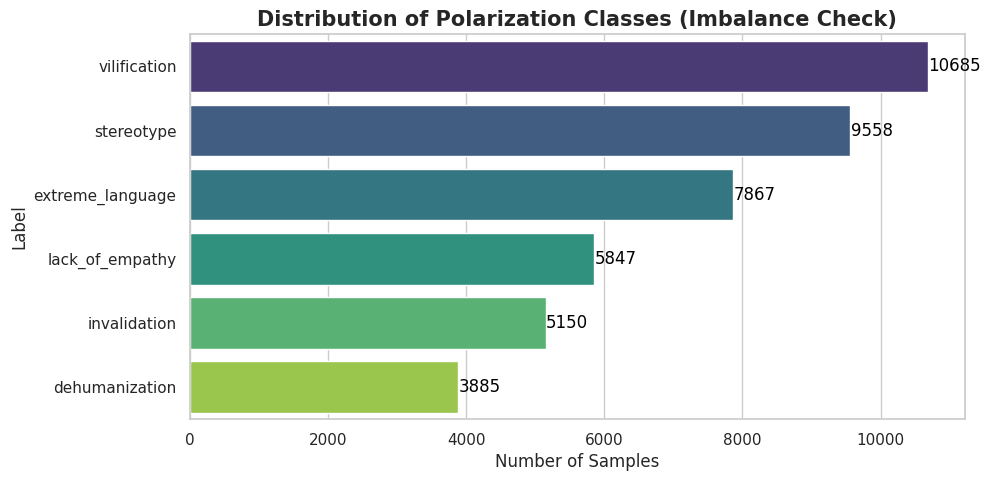

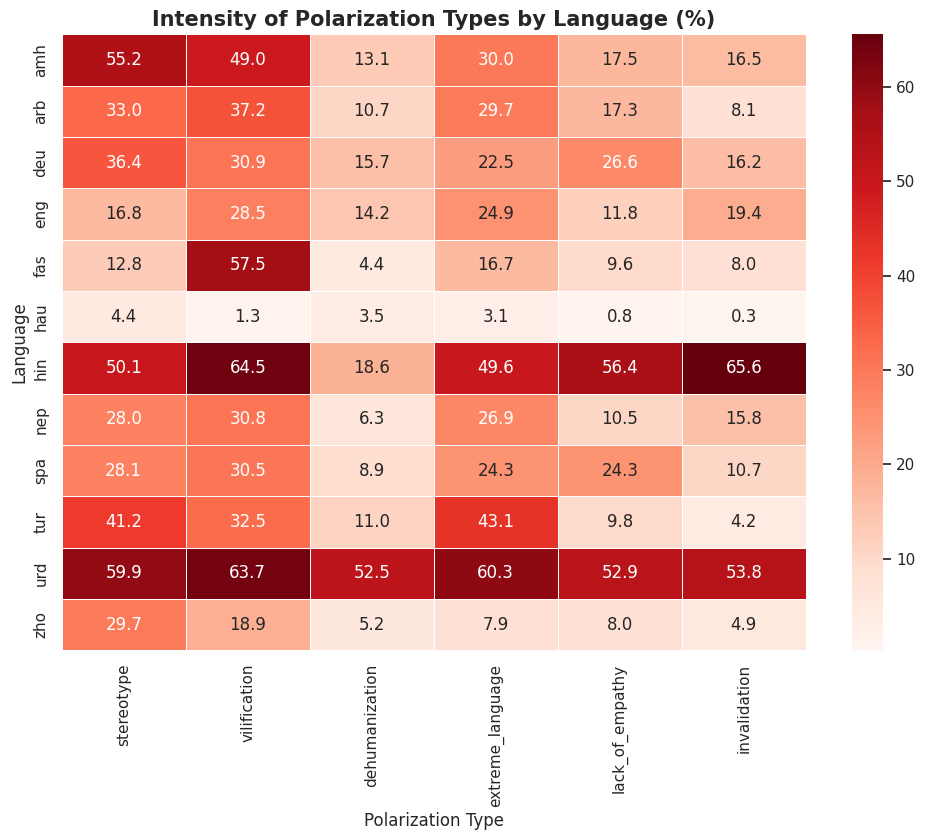

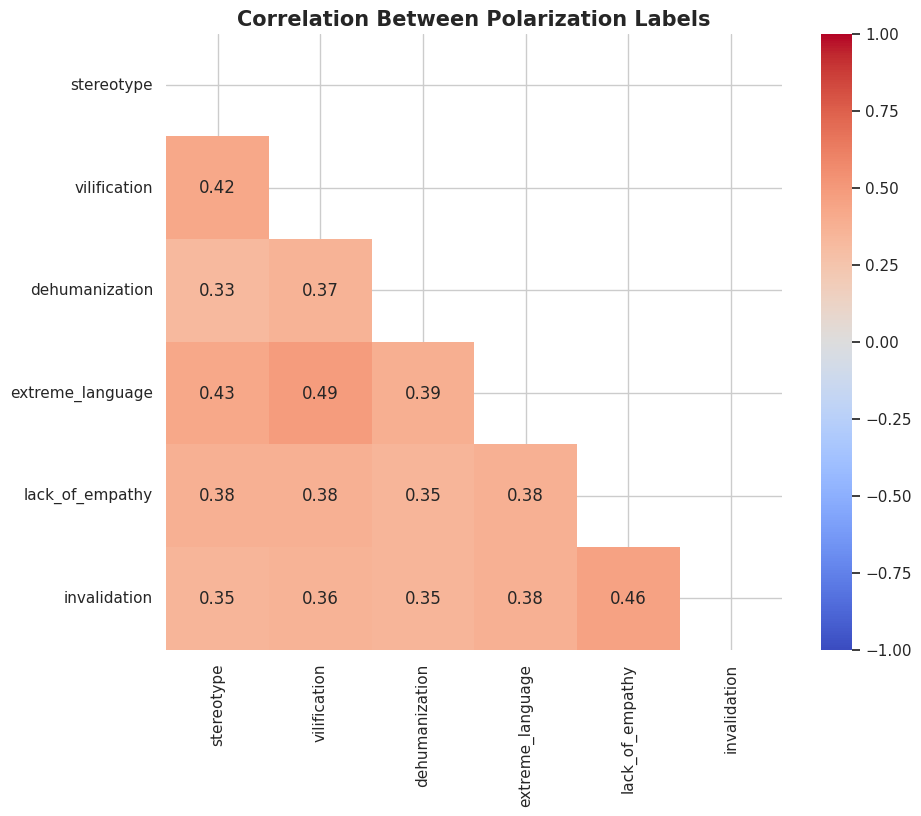

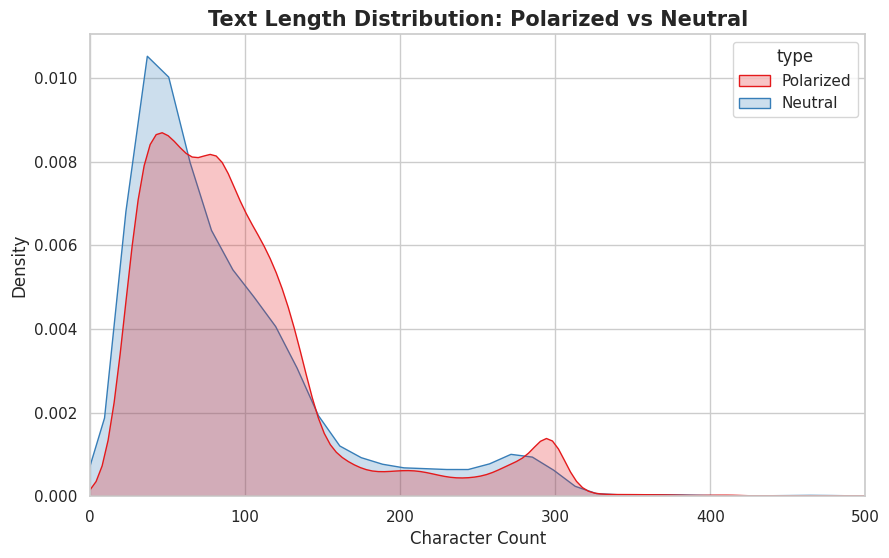

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

labels = CONFIG['LABEL_COLS']

#####

plt.figure(figsize=(10, 5))
label_counts = train_df[labels].sum().sort_values(ascending=False)
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")

plt.title("Distribution of Polarization Classes (Imbalance Check)", fontsize=15, fontweight='bold')
plt.xlabel("Number of Samples")
plt.ylabel("Label")
# Add numbers to bars
for i, v in enumerate(label_counts.values):
    ax.text(v + 10, i, str(v), color='black', va='center')
plt.show()

######


# Calculate polarization intensity per language
train_df['language'] = train_df['id'].apply(lambda x: x.split('_')[0])

lang_toxicity = train_df.groupby('language')[labels].sum()
lang_counts = train_df['language'].value_counts()
lang_toxicity_norm = lang_toxicity.div(lang_counts, axis=0) * 100

# Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(lang_toxicity_norm, annot=True, fmt=".1f", cmap="Reds", linewidths=.5)
plt.title("Intensity of Polarization Types by Language (%)", fontsize=15, fontweight='bold')
plt.ylabel("Language")
plt.xlabel("Polarization Type")
plt.show()

#####

plt.figure(figsize=(10, 8))
corr_matrix = train_df[labels].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Between Polarization Labels", fontsize=15, fontweight='bold')
plt.show()

#####
train_df['text_len'] = train_df['text'].str.len()
train_df['is_polarized'] = train_df[labels].sum(axis=1) > 0
train_df['type'] = train_df['is_polarized'].apply(lambda x: "Polarized" if x else "Neutral")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x="text_len", hue="type", fill=True, common_norm=False, palette="Set1")
plt.title("Text Length Distribution: Polarized vs Neutral", fontsize=15, fontweight='bold')
plt.xlabel("Character Count")
plt.xlim(0, 500) # Limit to readable range
plt.show()

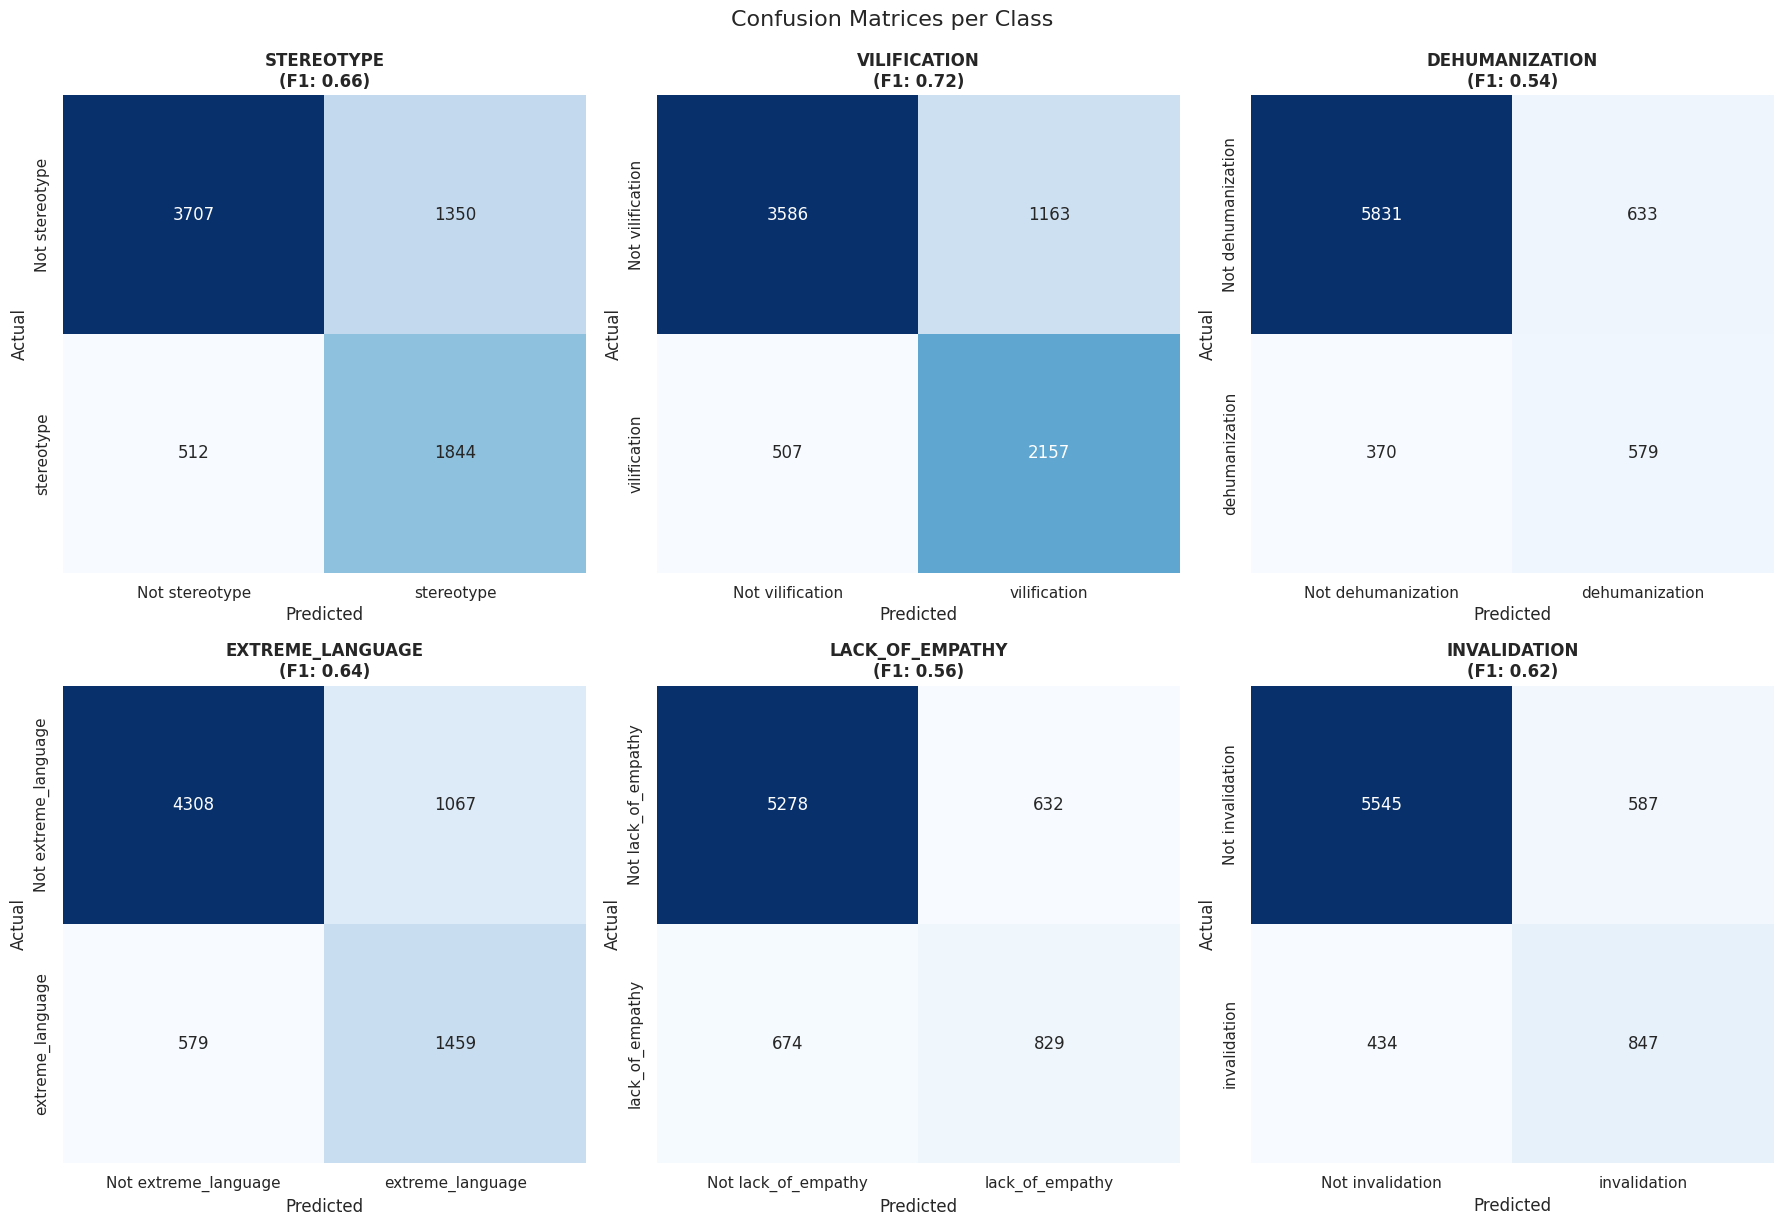

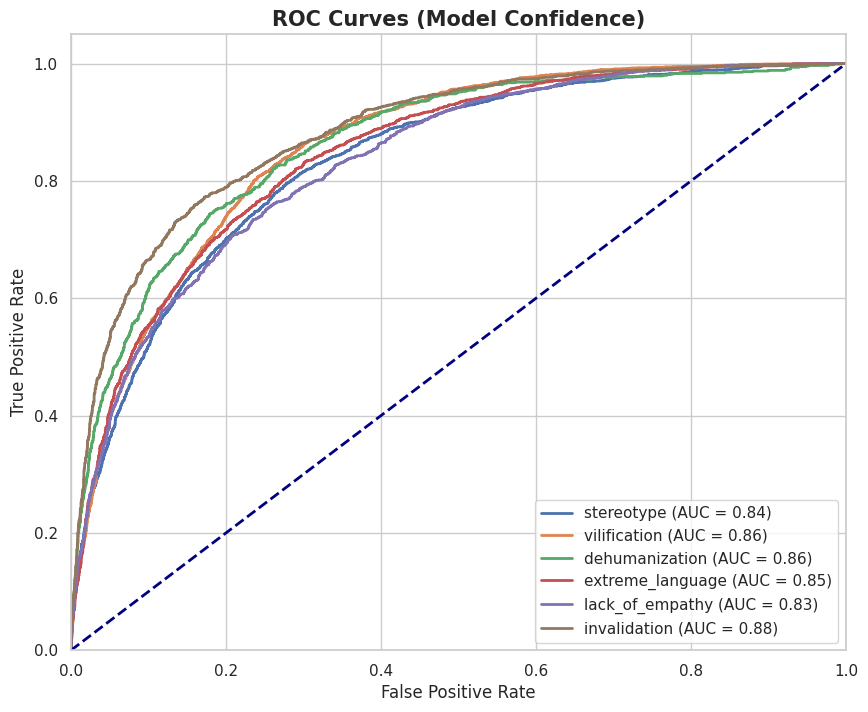

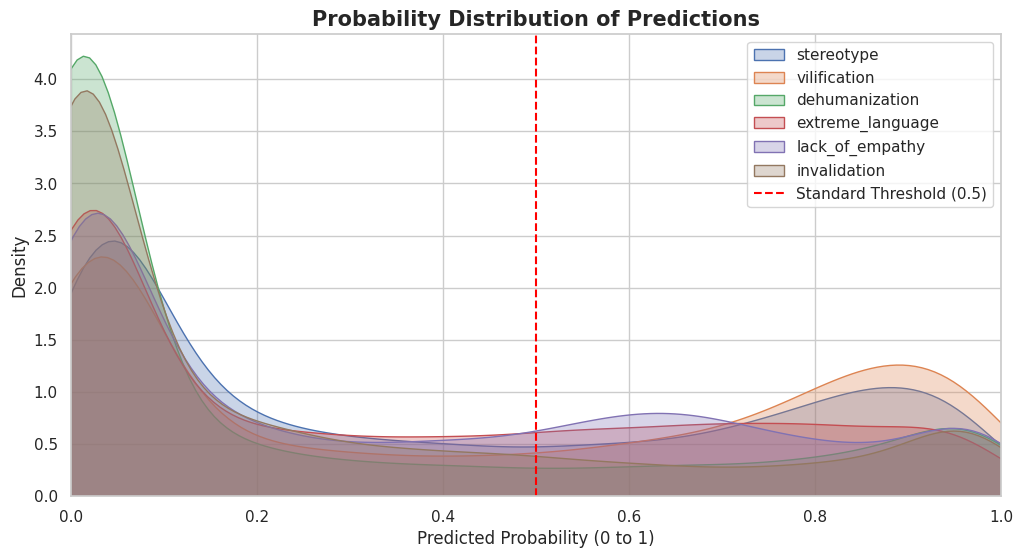

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score

model.eval()
val_probs = []
val_targets = []

with torch.no_grad():
    for batch in dev_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        outputs = model(input_ids=ids, attention_mask=mask)

        probs = torch.sigmoid(outputs.logits)

        val_probs.append(probs.cpu().numpy())
        val_targets.append(targets.cpu().numpy())

y_probs = np.concatenate(val_probs)
y_true = np.concatenate(val_targets)

try:
    thresh_list = optimal_thresholds
except NameError:
    thresh_list = [0.3] * len(CONFIG['LABEL_COLS'])

y_pred = np.zeros_like(y_probs)
for i, thresh in enumerate(thresh_list):
    y_pred[:, i] = (y_probs[:, i] > thresh).astype(int)


sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

### Confusion Matrix
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, label in enumerate(CONFIG['LABEL_COLS']):
    y_t = y_true[:, i]
    y_p = y_pred[:, i]

    cm = confusion_matrix(y_t, y_p)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Not ' + label, label],
                yticklabels=['Not ' + label, label])

    axes[i].set_title(f"{label.upper()}\n(F1: {f1_score(y_t, y_p):.2f})", fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.suptitle("Confusion Matrices per Class", y=1.02, fontsize=16)
plt.show()

#####ROC Curves confidence check
plt.figure(figsize=(10, 8))

for i, label in enumerate(CONFIG['LABEL_COLS']):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Model Confidence)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

#####Probability Histogram
plt.figure(figsize=(12, 6))
for i, label in enumerate(CONFIG['LABEL_COLS']):
    sns.kdeplot(y_probs[:, i], label=label, fill=True, alpha=0.3)

plt.title("Probability Distribution of Predictions", fontsize=15, fontweight='bold')
plt.xlabel("Predicted Probability (0 to 1)")
plt.ylabel("Density")
plt.xlim(0, 1)
plt.axvline(0.5, color='red', linestyle='--', label='Standard Threshold (0.5)')
plt.legend()
plt.show()

In [ ]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import os
import torch
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm.auto import tqdm

# ============================================================================
# 1. SETUP & LOADING SAVED WEIGHTS
# ============================================================================
MODEL_NAME = "google/rembert"

print(f"Loading Model Architecture: {MODEL_NAME}...")
# Re-initialize the architecture
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CONFIG['LABEL_COLS']),
    problem_type="multi_label_classification"
)

# Load your saved weights
save_path = os.path.join(CONFIG['SAVE_DIR'], "best_model.bin")
DRIVE_MODEL_PATH = "/content/drive/MyDrive/NLP_PROJECT_DATA/models/best_model.bin"

print(f"Loading weights from: {DRIVE_MODEL_PATH}")

# <--- CHANGED: Load state dict
if os.path.exists(DRIVE_MODEL_PATH):
    model.load_state_dict(torch.load(DRIVE_MODEL_PATH))
    print("Successfully loaded previous best model.")
else:
    print("Warning: Checkpoint not found! Starting from scratch.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ============================================================================
# 2. CONFIGURING OPTIMIZER FOR REMAINING EPOCHS
# ============================================================================

# Define where to start
START_EPOCH = 6
REMAINING_EPOCHS = TRAIN_PARAMS['EPOCHS'] - START_EPOCH

# Re-initialize Optimizer
optimizer = AdamW(model.parameters(), lr=TRAIN_PARAMS['LEARNING_RATE'], weight_decay=TRAIN_PARAMS['WEIGHT_DECAY'])

# Recalculate steps for the scheduler based on REMAINING epochs
# <--- CHANGED: Adjusted calculation for remaining steps
total_steps = len(train_loader) * REMAINING_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * TRAIN_PARAMS['WARMUP_RATIO']),
    num_training_steps=total_steps
)

# Define Weighted Loss (Same as before)
label_counts = train_df[CONFIG['LABEL_COLS']].sum()
pos_weights = [ (len(train_df) - c) / c if c > 0 else 1.0 for c in label_counts ]
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# ============================================================================
# 3. MODIFIED TRAINING LOOP
# ============================================================================

# <--- CHANGED: Reset best_val_f1.
# Since we loaded the "best" model, we assume the current performance is our baseline.
# If you know the specific F1 score you had, put it here. Otherwise 0.0 is fine.
best_val_f1 = 0.0
patience_counter = 0

print(f"\nResuming Training from Epoch {START_EPOCH+1} to {TRAIN_PARAMS['EPOCHS']}...")

# <--- CHANGED: Range starts from START_EPOCH
for epoch in range(START_EPOCH, TRAIN_PARAMS['EPOCHS']):

    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0

    loop = tqdm(train_loader, leave=True)
    for step, batch in enumerate(loop):
        ids = batch['ids'].to(device, dtype=torch.long)
        mask = batch['mask'].to(device, dtype=torch.long)
        targets = batch['targets'].to(device, dtype=torch.float)

        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits

        loss = criterion(logits, targets)
        loss = loss / CONFIG['GRAD_ACC_STEPS']
        loss.backward()
        total_train_loss += loss.item()

        if (step + 1) % CONFIG['GRAD_ACC_STEPS'] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_PARAMS['MAX_GRAD_NORM'])
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        loop.set_description(f"Epoch {epoch+1}/{TRAIN_PARAMS['EPOCHS']}")
        loop.set_postfix(loss=loss.item() * CONFIG['GRAD_ACC_STEPS'])

    avg_train_loss = total_train_loss / len(train_loader) * CONFIG['GRAD_ACC_STEPS']

    # --- VALIDATION PHASE ---
    model.eval()
    val_logits = []
    val_targets = []
    total_val_loss = 0

    with torch.no_grad():
        for batch in dev_loader:
            ids = batch['ids'].to(device, dtype=torch.long)
            mask = batch['mask'].to(device, dtype=torch.long)
            targets = batch['targets'].to(device, dtype=torch.float)

            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, targets)
            total_val_loss += loss.item()

            val_logits.append(outputs.logits)
            val_targets.append(targets)

    val_logits = torch.cat(val_logits, dim=0)
    val_targets = torch.cat(val_targets, dim=0)

    metrics = calculate_metrics(val_logits, val_targets)
    val_macro_f1 = metrics['macro_f1']

    print(f"\nEpoch {epoch+1} Summary:")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {total_val_loss/len(dev_loader):.4f}")
    print(f"   Val Macro F1: {val_macro_f1:.4f}")

    # --- SAVE & EARLY STOPPING ---
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        save_path = os.path.join(CONFIG['SAVE_DIR'], "best_model.bin")
        torch.save(model.state_dict(), save_path)
        print(f"Model Saved! (New Best F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{TRAIN_PARAMS['PATIENCE']}")

# Save the final model state as well
last_model_path = os.path.join(CONFIG['SAVE_DIR'], "last_model.bin")
torch.save(model.state_dict(), last_model_path)
print("\nResumed Training Complete.")

Loading Model Architecture: google/rembert...


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

Some weights of RemBertForSequenceClassification were not initialized from the model checkpoint at google/rembert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...


Epoch 5 Summary:
   Train Loss: 0.3818 | Val Loss: 0.8754
   Val Macro F1: 0.6059
Model Saved! (New Best F1: 0.6059)


  0%|          | 0/3706 [00:00<?, ?it/s]


Epoch 6 Summary:
   Train Loss: 0.3187 | Val Loss: 0.9516
   Val Macro F1: 0.5913
No improvement. Patience: 1/3


  0%|          | 0/3706 [00:00<?, ?it/s]

KeyboardInterrupt: 